# O1 5D fixed-depth analysis

This notebook compares fixed RF surrogate depths **5, 8, 12, 15, and 20** on the 5-dimensional O1 deterministic benchmark. Each depth uses the same five SMAC seeds, 10 instances, 1,500 trials, and 0% random-design injection.

All plots use a **linear regret axis**. Confidence intervals describe variation across the five paired SMAC seeds; with only five seeds, they are necessarily uncertain.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

DEPTHS = (5, 8, 12, 15, 20)
SEEDS = tuple(range(5))
N_TRIALS = 1500
CHECKPOINTS = (100, 250, 500, 750, 1000, 1250, 1500)
COLORS = dict(zip(DEPTHS, plt.cm.viridis(np.linspace(0.08, 0.92, len(DEPTHS)))))

candidates = [
    Path.cwd(),
    Path.cwd() / 'experiments/synthaticBench/o1_deterministic/depth_policies/08_5d',
]
HERE = next((p for p in candidates if (p / 'o1_5d_fixed_depth_runner.py').exists()), None)
if HERE is None:
    raise FileNotFoundError('Run from the notebook directory or repository root.')
OUTPUT = HERE / 'smac_output'
print(f'Experiment directory: {HERE.resolve()}')

Experiment directory: /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/o1_deterministic/depth_policies/08_5d


## Load and validate trajectories

In [2]:
rows = []
curves = {}

for path in sorted(OUTPUT.rglob('trajectory.json')):
    data = json.loads(path.read_text())
    depth = int(data['max_depth'])
    seed = int(data['smac_seed'])
    if depth not in DEPTHS or seed not in SEEDS:
        continue
    key = (depth, seed)
    if key in curves:
        raise ValueError(f'Duplicate trajectory for depth/seed {key}')
    best_regret = np.asarray(data['best_regret'], dtype=float)
    curves[key] = best_regret
    rows.append({
        'max_depth': depth,
        'smac_seed': seed,
        'final_regret': float(best_regret[-1]),
        'n_trials': int(data['n_trials']),
        'dimension': int(data['dimension']),
        'n_instances': int(data['n_instances']),
        'benchmark_seed': int(data['benchmark_seed']),
        'random_design_probability': float(data['random_design_probability']),
        'min_samples_leaf': int(data['min_samples_leaf']),
        'min_samples_split': int(data['min_samples_split']),
        'path': path,
    })

results = pd.DataFrame(rows).sort_values(['max_depth', 'smac_seed']).reset_index(drop=True)
if results.empty:
    raise FileNotFoundError(f'No trajectories found below {OUTPUT}.')

bad = results.query(
    'n_trials != 1500 or dimension != 5 or n_instances != 10 or '
    'benchmark_seed != 52 or random_design_probability != 0.0'
)
if not bad.empty:
    display(bad)
    raise ValueError('Found trajectories with incompatible metadata.')

missing = [(depth, seed) for depth in DEPTHS for seed in SEEDS if (depth, seed) not in curves]
wrong_lengths = {key: len(values) for key, values in curves.items() if len(values) != N_TRIALS}
print(f'Loaded {len(results)}/25 expected trajectories.')
print(f'Missing depth/seed pairs: {missing or "none"}')
print(f'Unexpected trajectory lengths: {wrong_lengths or "none"}')
display(results.groupby('max_depth').agg(runs=('smac_seed', 'nunique'), final_mean=('final_regret', 'mean'), final_median=('final_regret', 'median')))

Loaded 25/25 expected trajectories.
Missing depth/seed pairs: none
Unexpected trajectory lengths: none


,runs,final_mean,final_median
max_depth,,,
5,5,4240.787096,4459.884615
8,5,3141.836383,3569.835591
12,5,2370.762308,2389.914326
15,5,2395.702195,1960.313017
20,5,2033.382187,1911.123713


## Optimization progress with 95% confidence intervals

The solid line is mean best regret across SMAC seeds. Shading is a two-sided 95% Student-t confidence interval for that mean. Lower is better.

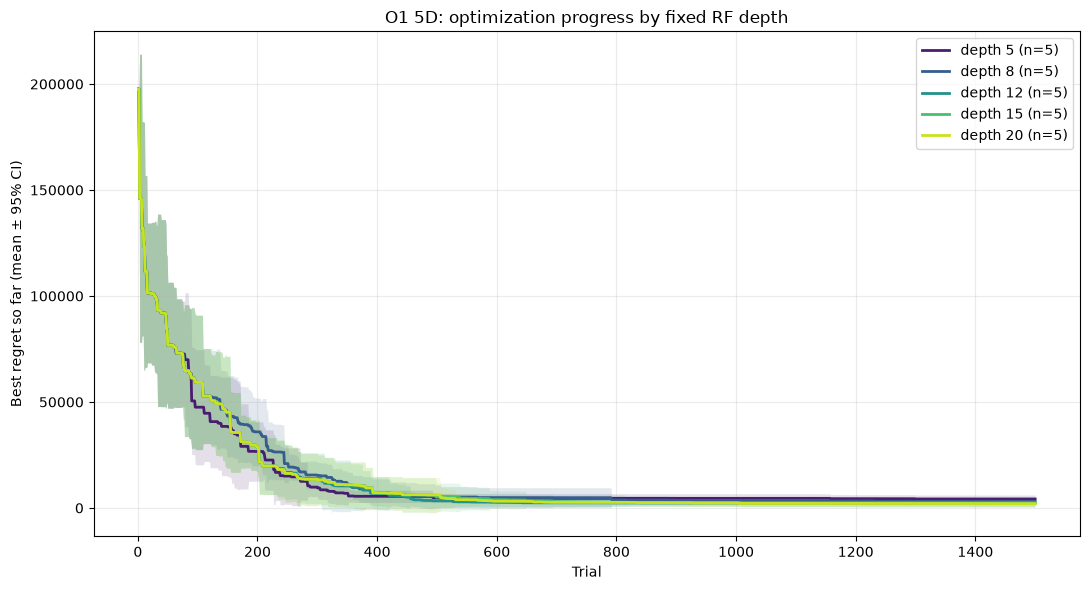

In [3]:
T_CRIT_95 = {2: 12.7062047364, 3: 4.3026527297, 4: 3.1824463053, 5: 2.7764451052}

def curve_summary(depth: int):
    series = [curves[(depth, seed)] for seed in SEEDS if (depth, seed) in curves]
    min_len = min(map(len, series))
    arr = np.vstack([values[:min_len] for values in series])
    mean = arr.mean(axis=0)
    if len(arr) < 2:
        half_width = np.zeros_like(mean)
    else:
        half_width = T_CRIT_95.get(len(arr), 1.96) * arr.std(axis=0, ddof=1) / np.sqrt(len(arr))
    return np.arange(1, min_len + 1), mean, half_width, len(arr)

fig, ax = plt.subplots(figsize=(11, 6))
for depth in DEPTHS:
    iteration, mean, half_width, n = curve_summary(depth)
    color = COLORS[depth]
    ax.plot(iteration, mean, color=color, linewidth=2, label=f'depth {depth} (n={n})')
    ax.fill_between(iteration, mean - half_width, mean + half_width, color=color, alpha=0.14, linewidth=0)
ax.set(xlabel='Trial', ylabel='Best regret so far (mean ± 95% CI)', title='O1 5D: optimization progress by fixed RF depth')
ax.set_yscale('linear')
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

## Final-regret distributions

Each boxplot contains the five final regrets, one from each paired SMAC seed. The points expose all observations so the small sample size stays visible.

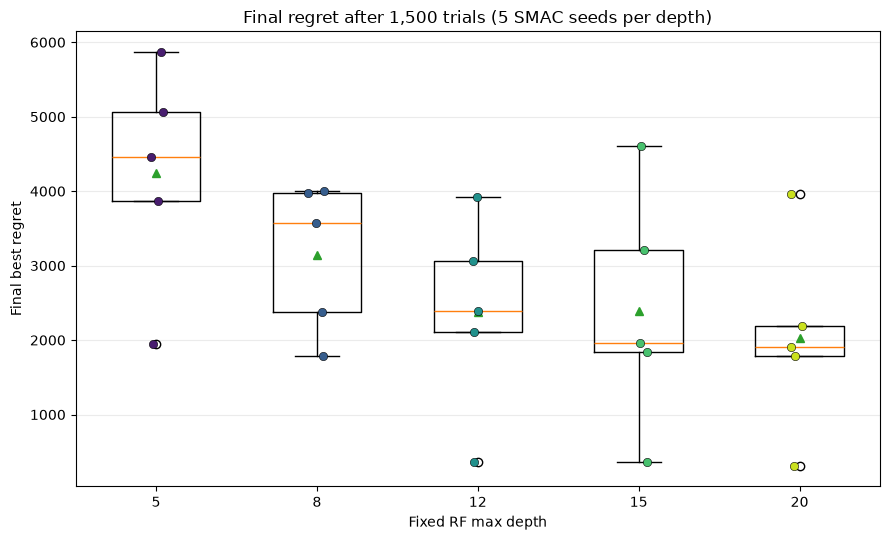

In [4]:
fig, ax = plt.subplots(figsize=(9, 5.5))
data = [results.query('max_depth == @depth')['final_regret'].to_numpy() for depth in DEPTHS]
bp = ax.boxplot(data, tick_labels=[str(d) for d in DEPTHS], showmeans=True, widths=0.55)
rng = np.random.default_rng(7)
for x, (depth, values) in enumerate(zip(DEPTHS, data), start=1):
    jitter = rng.uniform(-0.055, 0.055, size=len(values))
    ax.scatter(x + jitter, values, color=COLORS[depth], edgecolor='black', linewidth=0.4, zorder=3)
ax.set(xlabel='Fixed RF max depth', ylabel='Final best regret', title='Final regret after 1,500 trials (5 SMAC seeds per depth)')
ax.set_yscale('linear')
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
plt.show()

## Paired comparison by SMAC seed

Because all depths use the same SMAC seeds, connecting equal seeds helps distinguish a consistent depth effect from seed-specific difficulty.

max_depth,5,8,12,15,20
smac_seed,,,,,
0,"3,862","4,003","2,104","1,960","1,790"
1,"5,066","3,972",368.1,364,311.5
2,"5,869","1,785","3,066","3,204","2,186"
3,"4,460","2,380","3,926","4,604","3,968"
4,"1,947","3,570","2,390","1,846","1,911"


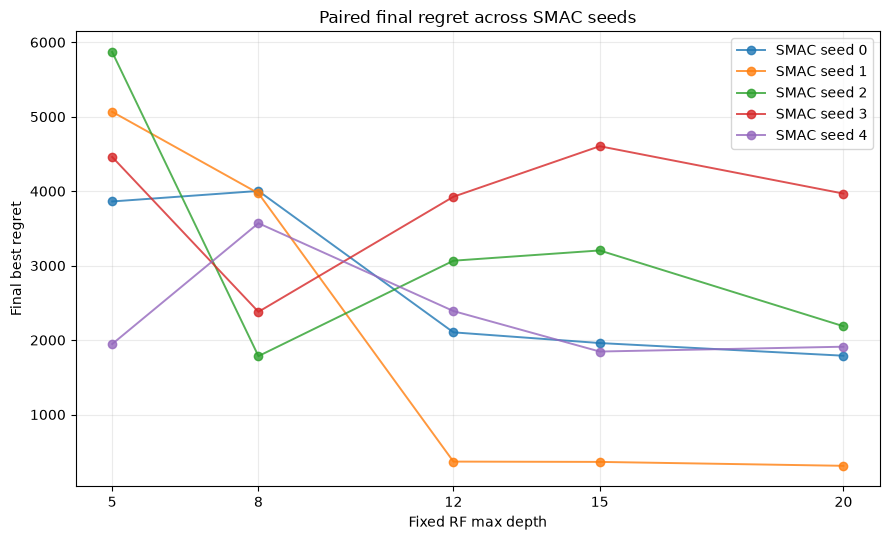

In [5]:
paired = results.pivot(index='smac_seed', columns='max_depth', values='final_regret').reindex(columns=DEPTHS)
display(paired.style.format('{:,.4g}'))

fig, ax = plt.subplots(figsize=(9, 5.5))
for seed, row in paired.iterrows():
    ax.plot(DEPTHS, row, marker='o', linewidth=1.4, alpha=0.8, label=f'SMAC seed {seed}')
ax.set(xlabel='Fixed RF max depth', ylabel='Final best regret', title='Paired final regret across SMAC seeds')
ax.set_xticks(DEPTHS)
ax.set_yscale('linear')
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

## Checkpoint comparison

This shows whether the preferred depth changes over the optimization budget. All panels share the same y-axis scale for direct comparison.

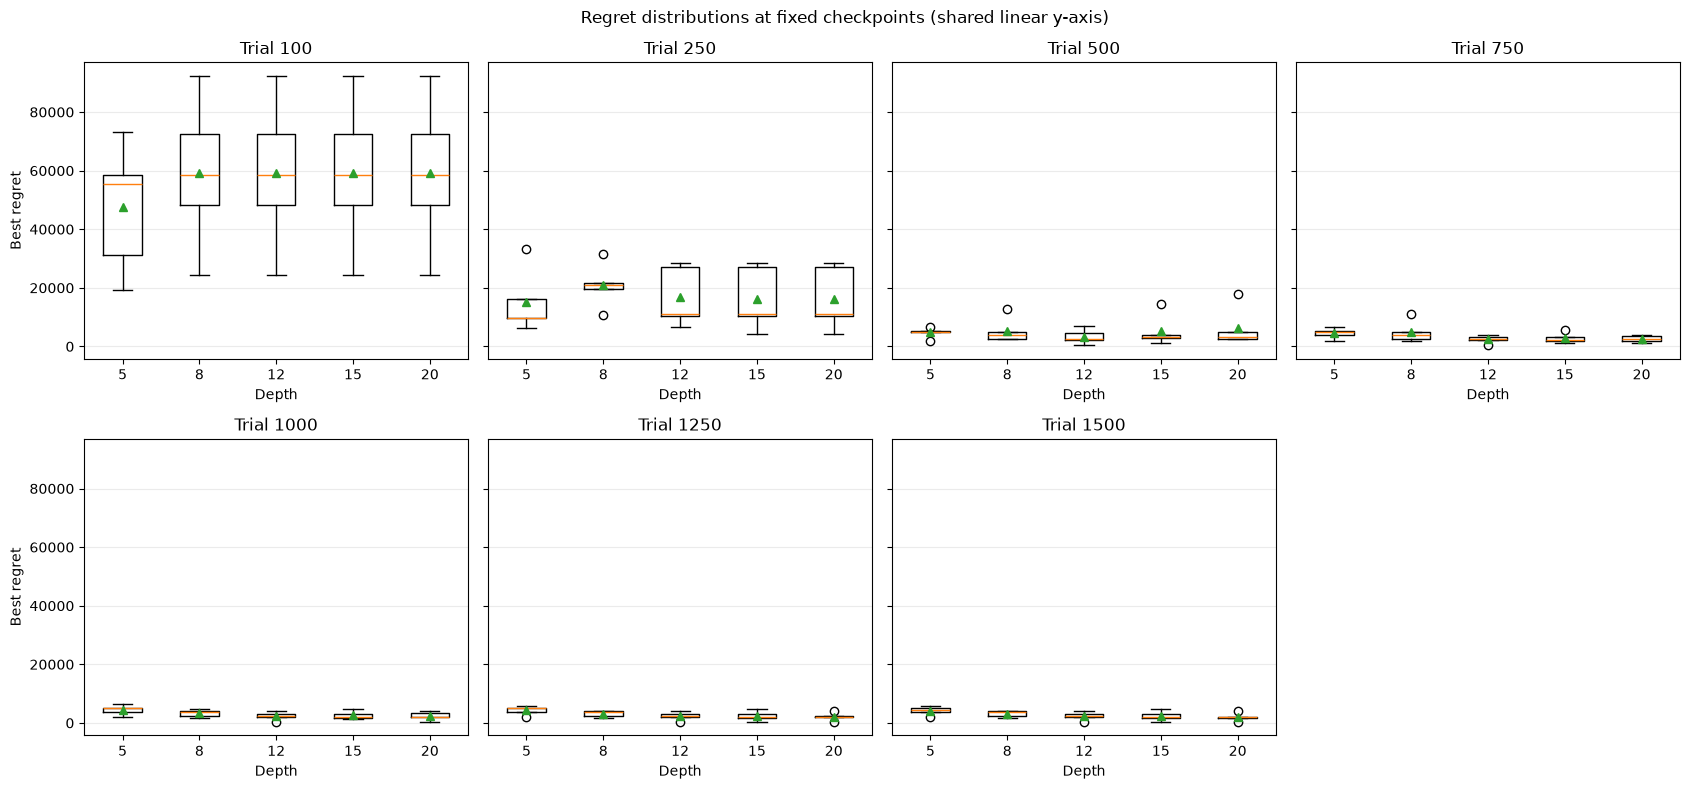

In [6]:
checkpoint_rows = []
for (depth, seed), values in curves.items():
    for checkpoint in CHECKPOINTS:
        if len(values) >= checkpoint:
            checkpoint_rows.append({'max_depth': depth, 'smac_seed': seed, 'checkpoint': checkpoint, 'best_regret': float(values[checkpoint - 1])})
checkpoint_df = pd.DataFrame(checkpoint_rows)

fig, axes = plt.subplots(2, 4, figsize=(17, 8), sharey=True)
for ax, checkpoint in zip(axes.flat, CHECKPOINTS):
    subset = checkpoint_df.query('checkpoint == @checkpoint')
    values = [subset.query('max_depth == @depth')['best_regret'].to_numpy() for depth in DEPTHS]
    ax.boxplot(values, tick_labels=[str(d) for d in DEPTHS], showmeans=True)
    ax.set_title(f'Trial {checkpoint}')
    ax.set_xlabel('Depth')
    ax.grid(axis='y', alpha=0.25)
for ax in axes[:, 0]:
    ax.set_ylabel('Best regret')
axes.flat[-1].axis('off')
fig.suptitle('Regret distributions at fixed checkpoints (shared linear y-axis)')
fig.tight_layout()
plt.show()

## Numerical summaries and ranks

In [7]:
final_summary = (
    results.groupby('max_depth')['final_regret']
    .agg(n='count', mean='mean', std='std', median='median', minimum='min', maximum='max')
)
final_summary['sem'] = final_summary['std'] / np.sqrt(final_summary['n'])
final_summary['ci95_low'] = final_summary['mean'] - 2.7764451052 * final_summary['sem']
final_summary['ci95_high'] = final_summary['mean'] + 2.7764451052 * final_summary['sem']
display(final_summary.sort_values('mean').style.format('{:,.4g}'))

seed_ranks = paired.rank(axis=1, method='average', ascending=True)
rank_summary = pd.DataFrame({
    'mean_rank': seed_ranks.mean(),
    'median_rank': seed_ranks.median(),
    'times_best': (seed_ranks == 1).sum(),
}).sort_values('mean_rank')
print('Depth ranks within each paired SMAC seed (1 = best):')
display(seed_ranks)
display(rank_summary)

,n,mean,std,median,minimum,maximum,sem,ci95_low,ci95_high
max_depth,,,,,,,,,
20,5,"2,033","1,304","1,911",311.5,"3,968",583.3,413.9,"3,653"
12,5,"2,371","1,321","2,390",368.1,"3,926",590.9,730.1,"4,011"
15,5,"2,396","1,593","1,960",364,"4,604",712.3,417.9,"4,373"
8,5,"3,142","1,005","3,570","1,785","4,003",449.2,"1,895","4,389"
5,5,"4,241","1,482","4,460","1,947","5,869",662.8,"2,400","6,081"


Depth ranks within each paired SMAC seed (1 = best):


max_depth,5,8,12,15,20
smac_seed,,,,,
0,4.0,5.0,3.0,2.0,1.0
1,5.0,4.0,3.0,2.0,1.0
2,5.0,1.0,3.0,4.0,2.0
3,4.0,1.0,2.0,5.0,3.0
4,3.0,5.0,4.0,1.0,2.0


,mean_rank,median_rank,times_best
max_depth,,,
20,1.8,2.0,2
15,2.8,2.0,1
12,3.0,3.0,0
8,3.2,4.0,2
5,4.2,4.0,0


## Interpretation checklist

When interpreting the results, distinguish these questions:

1. **Final performance:** Which depth has the smallest mean/median regret after 1,500 trials?
2. **Consistency:** Does the same depth win across several paired SMAC seeds, or is its mean driven by one run?
3. **Budget dependence:** Do checkpoint rankings change systematically as the trial budget grows?
4. **Uncertainty:** Do apparent gaps remain meaningful relative to the confidence intervals and five-point distributions?

A dynamic-depth motivation would require reasonably consistent budget-dependent changes, not merely crossing mean curves with strongly overlapping uncertainty intervals.